# 1. Import Library

In [1]:
# Import libraries for handling files and data
import os                  # To interact with the operating system (e.g., file paths)
import json                # To read and write JSON files
import pandas as pd        # For tabular data manipulation
import geopandas as gpd    # For spatial/geospatial data handling
from shapely.geometry import shape  # For creating/manipulating geometric objects

# Libraries for supervised classification
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier for supervised learning
from sklearn.model_selection import train_test_split, GridSearchCV  # Split data and tune hyperparameters
from sklearn.metrics import (
    confusion_matrix,      # Confusion matrix
    accuracy_score,        # Accuracy metric
    classification_report, # Detailed classification report
    ConfusionMatrixDisplay # To visualize confusion matrices
)

# Libraries for visualization
import matplotlib.pyplot as plt    # Standard plotting library
import folium                      # Interactive maps library
from shapely.geometry import mapping  # Convert shapely geometries into GeoJSON format for Folium

import warnings
warnings.filterwarnings('ignore')

# 2. Open and clean the dataframe

In [2]:
DIR_PATH = r'C:\Users\Roya\Downloads\Topic_6a'
CSV_NAME = 'stats_PAC_Sentinel2_Marcilla.csv'

In [3]:
df = pd.read_csv(os.path.join(DIR_PATH, CSV_NAME))
df.head(2)

,system:index,Blue,COEF_AUTO,COEF_REGAD,COMARCA,ClasEsp,ClasGen,EVI,GEOM_AREA,Green,...,RE3,RE4,RECINTO,REFCAT,Red,SAVI,SWIR1,SWIR2,date,.geo
0,20170320T105731_20170320T110651_T30TWM_0000000...,0.089959,96,0,Ribera Alta,PASTOS HERBÁCEOS,PASTOS,0.206017,1.225675e+09,0.133264,...,0.284415,0.317898,3.0,1.630301e+12,0.161433,0.206565,0.375248,0.287836,2017-03-20T11:09:26,"{""type"":""Polygon"",""coordinates"":[[[-1.71611337..."
1,20170320T105731_20170320T110651_T30TWM_0000000...,0.056875,85,0,Ribera Alta,PASTOS HERBÁCEOS,PASTOS,0.391653,1.225675e+09,0.101876,...,0.309520,0.336672,1.0,1.630301e+12,0.095817,0.377178,0.271447,0.182487,2017-03-20T11:09:26,"{""type"":""MultiPolygon"",""coordinates"":[[[[-1.71..."


In [4]:
df.columns

Index(['system:index', 'Blue', 'COEF_AUTO', 'COEF_REGAD', 'COMARCA', 'ClasEsp',
       'ClasGen', 'EVI', 'GEOM_AREA', 'Green', 'IDCOMARCA', 'IDClasEsp',
       'IDClasGen', 'MUNICIPIO', 'NDVI', 'NIR', 'PARCELA', 'POLIGONO',
       'PRD_CODIGO', 'PRD_DESC_1', 'PROVINCIA', 'RE1', 'RE2', 'RE3', 'RE4',
       'RECINTO', 'REFCAT', 'Red', 'SAVI', 'SWIR1', 'SWIR2', 'date', '.geo'],
      dtype='object')

In [5]:
# List of Sentinel-2 spectral bands that we will use as features
band_names = ['Blue','Green','Red', 'RE1', 'RE2', 'RE3', 'RE4','NIR','SWIR1', 'SWIR2', 'NDVI']
# Select only the relevant columns for classification
df = df[['ClasEsp','MUNICIPIO','POLIGONO','PARCELA','RECINTO','date','.geo'] + band_names ]
# Display the first 5 rows to verify
print(df.columns)
df.head(2)

Index(['ClasEsp', 'MUNICIPIO', 'POLIGONO', 'PARCELA', 'RECINTO', 'date',
       '.geo', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'RE4', 'NIR',
       'SWIR1', 'SWIR2', 'NDVI'],
      dtype='object')


,ClasEsp,MUNICIPIO,POLIGONO,PARCELA,RECINTO,date,.geo,Blue,Green,Red,RE1,RE2,RE3,RE4,NIR,SWIR1,SWIR2,NDVI
0,PASTOS HERBÁCEOS,163,3,585.0,3.0,2017-03-20T11:09:26,"{""type"":""Polygon"",""coordinates"":[[[-1.71611337...",0.089959,0.133264,0.161433,0.217575,0.264544,0.284415,0.317898,0.292339,0.375248,0.287836,0.291153
1,PASTOS HERBÁCEOS,163,3,705.0,1.0,2017-03-20T11:09:26,"{""type"":""MultiPolygon"",""coordinates"":[[[[-1.71...",0.056875,0.101876,0.095817,0.164091,0.282563,0.309520,0.336672,0.326986,0.271447,0.182487,0.558616


## Preparing Data

#### Create parcel ID and convert to geodataframe

In [6]:
# Creating Parcel ID by Combining the four columns into a single string separated by '-' to create a unique ID
for column in ['MUNICIPIO','POLIGONO','PARCELA','RECINTO']:
    df[column] = df[column].astype(int).astype(str) 
del column
df['parcelID'] = df[['MUNICIPIO','POLIGONO','PARCELA','RECINTO']].agg('-'.join, axis=1)
df = df.drop(columns=['MUNICIPIO','POLIGONO','PARCELA','RECINTO'])

# Convert dataframe to geodataframe
df['geometry'] = df['.geo'].apply(lambda x: shape(json.loads(x)))
del df['.geo']
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')

# Print current CRS
print('Initial CRS:', gdf.crs)
# Reproject the GeoDataFrame to a metric CRS (UTM zone 30N) for accurate area calculations
gdf = gdf.to_crs('EPSG:25830')
# Calculate parcel area in hectares (1 ha = 10,000 m²)
gdf['area_ha'] = gdf['geometry'].area / 10000
# Split the 'date' column at 'T' and keep only the first part (YYYY-MM-DD)
gdf['new_date'] = gdf['date'].str.split('T').str[0]

print('New CRS:', gdf.crs)
print (gdf.columns)
gdf.head(2)

Initial CRS: EPSG:4326
New CRS: EPSG:25830
Index(['ClasEsp', 'date', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'RE4',
       'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'parcelID', 'geometry', 'area_ha',
       'new_date'],
      dtype='object')


,ClasEsp,date,Blue,Green,Red,RE1,RE2,RE3,RE4,NIR,SWIR1,SWIR2,NDVI,parcelID,geometry,area_ha,new_date
0,PASTOS HERBÁCEOS,2017-03-20T11:09:26,0.089959,0.133264,0.161433,0.217575,0.264544,0.284415,0.317898,0.292339,0.375248,0.287836,0.291153,163-3-585-3,"POLYGON ((605780.634 4687049.497, 605786.098 4...",0.045898,2017-03-20
1,PASTOS HERBÁCEOS,2017-03-20T11:09:26,0.056875,0.101876,0.095817,0.164091,0.282563,0.309520,0.336672,0.326986,0.271447,0.182487,0.558616,163-3-705-1,"MULTIPOLYGON (((606285.956 4686904.558, 606286...",2.025504,2017-03-20


#### Pivoting the Data

In [7]:
# --- Step 1: Get all unique dates in the dataset ---
dates = gdf['new_date'].unique()  # List of acquisition dates

# --- Step 2: Organize the data of the dataframe ---
# Pivot the table: rows = parcelID, columns = band_date, values = reflectance
gdf_pivot = gdf.pivot_table(
    index=['parcelID','ClasEsp','area_ha'],  columns='new_date', values=band_names)

#Create a list with the new names of the columns
new_column_names = [f'{band}_{date}' for band, date in gdf_pivot.columns]

#Flatten the multi-level columns (band, date) to 'band_date'
gdf_pivot.columns = new_column_names
gdf_pivot = gdf_pivot.reset_index()

# Add geometry data
gdf_pivot = gdf_pivot.merge(gdf[['parcelID','geometry']].drop_duplicates(), on = 'parcelID', how = 'inner')

print('Number of rows:',len(gdf_pivot))
gdf_pivot.head(2)

Number of rows: 1060


,parcelID,ClasEsp,area_ha,Blue_2017-03-20,Blue_2017-04-09,Blue_2017-04-19,Blue_2017-05-19,Blue_2017-05-24,Blue_2017-06-18,Blue_2017-06-28,...,SWIR2_2017-09-16,SWIR2_2017-10-06,SWIR2_2017-10-11,SWIR2_2017-10-16,SWIR2_2017-10-26,SWIR2_2017-12-05,SWIR2_2017-12-15,SWIR2_2017-12-20,SWIR2_2017-12-30,geometry
0,163-1-102-1,PASTOS HERBÁCEOS,0.109207,0.026095,0.033568,0.033579,0.018225,NaN,0.049925,0.224565,...,0.0386,0.120800,0.148023,0.157707,0.138111,0.134996,NaN,0.214058,0.130270,"POLYGON ((603524.564 4687613.887, 603536.974 4..."
1,163-1-104-5,BARBECHO,0.539439,0.014529,0.043537,0.038821,0.026600,NaN,0.072159,0.110534,...,NaN,0.189637,0.273997,0.284056,0.249375,0.218134,NaN,0.278811,0.179031,"POLYGON ((603582.642 4687539.926, 603587.607 4..."


## Descriptive Analysis

#### Translate Crops Name

In [8]:
# Check all unique crop names to see all the crop types in Spanish.
print('Unique value of Crops:', gdf['ClasEsp'].nunique())
gdf_pivot['ClasEsp'].unique() 

Unique value of Crops: 22


array(['PASTOS HERBÁCEOS', 'BARBECHO', 'VIÑA', 'MAÍZ', 'ALFALFA',
       'CEBADA', 'TRIGO', 'PASTOS ARBUSTIVOS', 'OLIVAR',
       'HORTÍCOLA DE VERANO', 'OTROS CULTIVOS HERBÁCEOS', 'FRUTALES',
       'SUPERFICIES FORESTALES', 'PASTOS ARBOLADOS', 'AVENA',
       'OTROS CULTIVOS PERMANENTES', 'HORTÍCOLA DE INVIERNO', 'TOMATE',
       'GIRASOL', 'ALMENDROS', 'GUISANTE', 'MEZCLAS CON CEREAL'],
      dtype=object)

In [9]:
# Dictionary to translate crop names from Spanish to English
crop_translation = {'PASTOS HERBÁCEOS':'GRASS', 'PASTOS ARBUSTIVOS': 'SHRUB-PASTURES', 'PASTOS ARBOLADOS':'WOODED-PASTURES',  'TRIGO':'WHEAT', 'CEBADA':'BARLEY',
                    'BARBECHO':'FALLOW', 'VIÑA':'VINEYARD', 'OLIVAR':'OLIVE', 'FRUTALES':'FRUIT-TREES', 'ALMENDROS': 'ALMONDS',
                    'MAÍZ':'CORN', 'GUISANTE':'PEA', 'MEZCLAS CON CEREAL': 'MIXED-CEREALS', 'SUPERFICIES FORESTALES': 'FOREST',
                    'OTROS CULTIVOS HERBÁCEOS': 'OTHER-HERBACEOUS-CROPS', 'OTROS CULTIVOS PERMANENTES': 'OTHER-PERMANENT-CROPS',
                    'HORTÍCOLA DE INVIERNO': 'WINTER-VEGETABLE', 'HORTÍCOLA DE VERANO':'SUMMER-VEGETABLES',
                    'AVENA': 'OAT', 'ALFALFA':'ALFALFA', 'GIRASOL':'SUNFLOWER', 'TOMATE': 'TOMATO'}

# Apply the translation dictionary to create a new 'Crop' column
gdf_pivot['Crop'] =gdf_pivot['ClasEsp'].map(crop_translation)
del gdf_pivot['ClasEsp']

# Display first 5 rows to verify the translation
print('Our dataframe has ',len(gdf_pivot),'rows.')
gdf_pivot.head(2)

Our dataframe has  1060 rows.


,parcelID,area_ha,Blue_2017-03-20,Blue_2017-04-09,Blue_2017-04-19,Blue_2017-05-19,Blue_2017-05-24,Blue_2017-06-18,Blue_2017-06-28,Blue_2017-07-03,...,SWIR2_2017-10-06,SWIR2_2017-10-11,SWIR2_2017-10-16,SWIR2_2017-10-26,SWIR2_2017-12-05,SWIR2_2017-12-15,SWIR2_2017-12-20,SWIR2_2017-12-30,geometry,Crop
0,163-1-102-1,0.109207,0.026095,0.033568,0.033579,0.018225,NaN,0.049925,0.224565,0.054338,...,0.120800,0.148023,0.157707,0.138111,0.134996,NaN,0.214058,0.130270,"POLYGON ((603524.564 4687613.887, 603536.974 4...",GRASS
1,163-1-104-5,0.539439,0.014529,0.043537,0.038821,0.026600,NaN,0.072159,0.110534,0.071983,...,0.189637,0.273997,0.284056,0.249375,0.218134,NaN,0.278811,0.179031,"POLYGON ((603582.642 4687539.926, 603587.607 4...",FALLOW


In [10]:
parcel_info = gdf_pivot.groupby('Crop').agg(
    num_parcels=('Crop', 'size'),  # Count how many parcels belong to each crop
).reset_index()
print("Parcel Information by Crop before remove small parcels")
print('Unique value of Crops:', gdf_pivot['Crop'].nunique())
print(parcel_info.sort_values('num_parcels',ascending = False).reset_index(drop = True))

Parcel Information by Crop before remove small parcels
Unique value of Crops: 22
                      Crop  num_parcels
0                    GRASS          181
1                   FALLOW          169
2                     CORN          168
3                    WHEAT          158
4                   BARLEY           98
5                  ALFALFA           97
6        SUMMER-VEGETABLES           27
7              FRUIT-TREES           24
8   OTHER-HERBACEOUS-CROPS           21
9                   FOREST           21
10                VINEYARD           16
11               SUNFLOWER           12
12          SHRUB-PASTURES           11
13                  TOMATO           11
14        WINTER-VEGETABLE           11
15                 ALMONDS           10
16                   OLIVE            9
17         WOODED-PASTURES            6
18   OTHER-PERMANENT-CROPS            4
19                     PEA            3
20                     OAT            2
21           MIXED-CEREALS            1

In [11]:
# Remove small parcels
min_parcel_size = 1.5
gdfclas_bigparcels = gdf_pivot.loc[gdf_pivot['area_ha'] >= min_parcel_size]
gdf_removed_parcels = gdf_pivot.loc[gdf_pivot['area_ha'] < min_parcel_size]
# Calculate data of interest
removed_parcels = len(gdf_removed_parcels)
removed_area = gdf_removed_parcels['area_ha'].sum()
remaining_area = gdfclas_bigparcels['area_ha'].sum()
print('{} parcels were removed: {:.1f} ha ({:.1f}% of the initial study area).'.format(len(gdf_removed_parcels), removed_area, 100*removed_area/(remaining_area+removed_area)))
print('{} parcels remained: {:.1f} ha ({:.1f}% of the initial study area).'.format(len(gdfclas_bigparcels),remaining_area,100*remaining_area/(remaining_area+removed_area)))

936 parcels were removed: 263.8 ha (25.9% of the initial study area).
124 parcels remained: 754.6 ha (74.1% of the initial study area).


In [12]:
parcel_info = gdfclas_bigparcels.groupby('Crop').agg(
    num_parcels=('Crop', 'size'),  # Count how many parcels belong to each crop
    total_ha=('area_ha', 'sum')    # Sum the area for each crop
).reset_index()

print("Parcel Information by Crop after remove small parcels")
print('Unique value of Crops:', gdfclas_bigparcels['Crop'].nunique())
total_area = parcel_info['total_ha'].sum()
print ('Total area:', total_area)

# Display information
print(parcel_info.sort_values('total_ha',ascending = False).reset_index(drop = True))

Parcel Information by Crop after remove small parcels
Unique value of Crops: 14
Total area: 754.6318479209183
                 Crop  num_parcels    total_ha
0              BARLEY           35  224.432842
1               WHEAT           20  139.137390
2                CORN           17  136.484586
3              TOMATO            7   56.874510
4            VINEYARD           10   48.806289
5              FALLOW            9   48.786777
6                 PEA            3   27.816528
7    WINTER-VEGETABLE            7   26.096901
8             ALFALFA            5   16.730143
9              FOREST            4   10.637037
10              GRASS            4    8.719670
11  SUMMER-VEGETABLES            1    5.118334
12     SHRUB-PASTURES            1    2.513926
13      MIXED-CEREALS            1    2.476915


In [13]:
# Keep only representative crops ---
min_parcels = 10  # Minimum number of parcels to consider a class representative
representative_crops = parcel_info.loc[parcel_info['num_parcels'] >= min_parcels, 'Crop'].values
print('Our representative classes are:', representative_crops)

# Filter dataframe to include only representative crops
gdfclas_bigparcels_repcrops = gdfclas_bigparcels.loc[gdfclas_bigparcels['Crop'].isin(representative_crops)].reset_index(drop=True)
print('We have now', len(gdfclas_bigparcels), 'parcels.')

Our representative classes are: ['BARLEY' 'CORN' 'VINEYARD' 'WHEAT']
We have now 124 parcels.


In [14]:
parcel_info = gdfclas_bigparcels_repcrops.groupby('Crop').agg(
    num_parcels=('Crop', 'size'),  # Count how many parcels belong to each crop
    total_ha=('area_ha', 'sum')    # Sum the area for each crop
).reset_index()

print('Unique value of Crops:', gdfclas_bigparcels_repcrops['Crop'].nunique())
total_area = parcel_info['total_ha'].sum()
print ('Total area:', total_area)

# Display information
print(parcel_info.sort_values('total_ha',ascending = False).reset_index(drop = True))

Unique value of Crops: 4
Total area: 548.8611070443092
       Crop  num_parcels    total_ha
0    BARLEY           35  224.432842
1     WHEAT           20  139.137390
2      CORN           17  136.484586
3  VINEYARD           10   48.806289


In [15]:
# Check for NaN values (missing data) ---
# Columns with all NaN
print('Number of columns with all NaN:', gdfclas_bigparcels_repcrops.isna().all().sum())

# Print initial dates
print(len(dates), 'initial dates:', dates)

# Remove columns containing any NaN
gdfclas_nonans = gdfclas_bigparcels_repcrops.dropna(axis=1, how='any')

# Final dates after removing NaNs
final_dates = set([x.split('_')[1] for x in gdfclas_nonans.columns if '-' in x])

print(len(final_dates), 'final dates:', list(final_dates))

Number of columns with all NaN: 11
22 initial dates: ['2017-03-20' '2017-04-09' '2017-04-19' '2017-05-19' '2017-05-24'
 '2017-06-18' '2017-06-28' '2017-07-03' '2017-07-13' '2017-07-18'
 '2017-07-28' '2017-08-17' '2017-09-06' '2017-09-16' '2017-10-06'
 '2017-10-11' '2017-10-16' '2017-10-26' '2017-12-05' '2017-12-15'
 '2017-12-20' '2017-12-30']
13 final dates: ['2017-07-13', '2017-03-20', '2017-08-17', '2017-07-18', '2017-10-26', '2017-10-16', '2017-07-03', '2017-12-05', '2017-10-11', '2017-07-28', '2017-04-19', '2017-04-09', '2017-06-18']


In [16]:
# Encode crop names as numbers for classifier ---
# Create the dictionary for the encoding
crop_to_number = {crop:number for crop,number in zip(representative_crops,range(1,len(representative_crops)+1))}
number_to_crop = {number:crop for crop,number in zip(representative_crops,range(1,len(representative_crops)+1))}

print (crop_to_number)

# Apply the translation dictionary to create a new 'Crop' column
gdfclas_nonans['Crop_number'] = gdfclas_nonans['Crop'].map(crop_to_number)

{'BARLEY': 1, 'CORN': 2, 'VINEYARD': 3, 'WHEAT': 4}


In [17]:
# Display the first 5 rows of the final dataframe
gdfclas_nonans.head(2)

,parcelID,area_ha,Blue_2017-03-20,Blue_2017-04-09,Blue_2017-04-19,Blue_2017-06-18,Blue_2017-07-03,Blue_2017-07-13,Blue_2017-07-18,Blue_2017-07-28,...,SWIR2_2017-07-18,SWIR2_2017-07-28,SWIR2_2017-08-17,SWIR2_2017-10-11,SWIR2_2017-10-16,SWIR2_2017-10-26,SWIR2_2017-12-05,geometry,Crop,Crop_number
0,163-3-473-1,1.938431,0.047341,0.021681,0.018465,0.056379,0.101000,0.105542,0.111685,0.117507,...,0.310171,0.322725,0.326946,0.338961,0.329078,0.310225,0.251672,"POLYGON ((606768.439 4687919.167, 606776.881 4...",BARLEY,1
1,163-3-490-2,4.963743,0.021950,0.009225,0.006483,0.054127,0.065592,0.094081,0.108954,0.088743,...,0.285005,0.275379,0.263469,0.275567,0.277389,0.258374,0.149765,"POLYGON ((606688.524 4687663.031, 606697.957 4...",WHEAT,4


# 5. Parcel Supervised Classification 

### Splitting Dataset

In [18]:
# --- Step 1: Select input features for the model ---
exclude_cols = ['parcelID', 'Crop', 'area_ha', 'Crop_number', 'geometry']
prefixes = ('Red', 'RE2', 'SWIR1', 'NDVI')

model_inputs = [
    x for x in gdfclas_nonans.columns
    if x not in exclude_cols and (
        ('-' in x and x.startswith(prefixes))
    )
]

X = gdfclas_nonans[model_inputs]  # Input features for the classifier
y = gdfclas_nonans['Crop_number']  # Target labels (encoded crop classes)

In [19]:
# Display the model inputs:
X.head(2)

,NDVI_2017-03-20,NDVI_2017-04-09,NDVI_2017-04-19,NDVI_2017-06-18,NDVI_2017-07-03,NDVI_2017-07-13,NDVI_2017-07-18,NDVI_2017-07-28,NDVI_2017-08-17,NDVI_2017-10-11,...,SWIR1_2017-06-18,SWIR1_2017-07-03,SWIR1_2017-07-13,SWIR1_2017-07-18,SWIR1_2017-07-28,SWIR1_2017-08-17,SWIR1_2017-10-11,SWIR1_2017-10-16,SWIR1_2017-10-26,SWIR1_2017-12-05
0,0.652651,0.932353,0.967253,0.282272,0.193494,0.189146,0.184797,0.122699,0.081561,0.159545,...,0.292695,0.399601,0.411728,0.417846,0.378490,0.396265,0.382778,0.378827,0.353051,0.297110
1,0.826529,0.971090,0.975174,0.294730,0.228226,0.226011,0.193896,0.202791,0.293048,0.285077,...,0.239505,0.259826,0.375583,0.409603,0.373248,0.388440,0.342806,0.343369,0.290700,0.193764


In [20]:
# Display the target labels
y.head(2)

0    1
1    4
Name: Crop_number, dtype: int64

In [21]:
# Split the dataset into training and testing sets ---
test_size = 0.2  # 20% of the data for testing, 80% for training

# Stratify ensures that the class distribution is similar in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, stratify=y, random_state=12
)

In [22]:
# --- Step 3: Display the number of parcels in each dataset ---
print('Number of parcels in train dataset (80%):', len(X_train))
print('Number of parcels in test dataset (20%):', len(X_test))

Number of parcels in train dataset (80%): 65
Number of parcels in test dataset (20%): 17


In [23]:
# Display the datasets
X_train.head(2)

,NDVI_2017-03-20,NDVI_2017-04-09,NDVI_2017-04-19,NDVI_2017-06-18,NDVI_2017-07-03,NDVI_2017-07-13,NDVI_2017-07-18,NDVI_2017-07-28,NDVI_2017-08-17,NDVI_2017-10-11,...,SWIR1_2017-06-18,SWIR1_2017-07-03,SWIR1_2017-07-13,SWIR1_2017-07-18,SWIR1_2017-07-28,SWIR1_2017-08-17,SWIR1_2017-10-11,SWIR1_2017-10-16,SWIR1_2017-10-26,SWIR1_2017-12-05
78,0.128581,0.090026,0.109199,0.282206,0.280855,0.259064,0.242792,0.248685,0.245620,0.256293,...,0.385644,0.410535,0.430894,0.420046,0.416591,0.394589,0.356092,0.383139,0.331418,0.273432
75,0.116749,0.077802,0.107089,0.349782,0.352388,0.349762,0.355035,0.330804,0.322545,0.337853,...,0.394158,0.366059,0.371058,0.360123,0.358964,0.344912,0.318861,0.356084,0.294359,0.309291


In [24]:
y_train.head(2)

78    3
75    3
Name: Crop_number, dtype: int64

In [25]:
X_test.head(2)

,NDVI_2017-03-20,NDVI_2017-04-09,NDVI_2017-04-19,NDVI_2017-06-18,NDVI_2017-07-03,NDVI_2017-07-13,NDVI_2017-07-18,NDVI_2017-07-28,NDVI_2017-08-17,NDVI_2017-10-11,...,SWIR1_2017-06-18,SWIR1_2017-07-03,SWIR1_2017-07-13,SWIR1_2017-07-18,SWIR1_2017-07-28,SWIR1_2017-08-17,SWIR1_2017-10-11,SWIR1_2017-10-16,SWIR1_2017-10-26,SWIR1_2017-12-05
35,0.880873,0.554892,0.768062,0.138771,0.326964,0.484506,0.509077,0.584843,0.864032,0.349191,...,0.440181,0.308162,0.272160,0.328974,0.287547,0.200016,0.354316,0.257516,0.271583,0.279811
38,0.925720,0.631818,0.823402,0.116735,0.291912,0.440722,0.476188,0.611365,0.916792,0.299717,...,0.432001,0.273333,0.245341,0.326251,0.256884,0.172850,0.345962,0.345977,0.263532,0.221232


In [26]:
y_test.head(2)

35    2
38    2
Name: Crop_number, dtype: int64

### Hyperparameter Optimization with GridSearchCV

In [27]:
# --- Step 1: Define the Random Forest classifier ---
RF = RandomForestClassifier(random_state=4242)

# --- Step 2: Define the hyperparameter grid ---
param_grid = {
    'n_estimators': [10,50,100],             # Number of trees
    'max_features': ['sqrt', 'log2', None],    # Max features considered for each split
    'criterion': ['gini', 'entropy'],          # Split quality metric
    'min_samples_split': [2,10,20]              # Minimum samples to split a node
}

# --- Step 3: GridSearchCV to test all combinations ---
classifier = GridSearchCV(
    RF, param_grid, scoring='accuracy', cv=5, return_train_score=True
)

# --- Step 4: Train all models with training data ---
classifier = classifier.fit(X_train, y_train)

# --- Step 5: Show the best hyperparameters and associated accuracy ---
print(classifier.best_params_)
print(classifier.best_score_)


{'criterion': 'gini', 'max_features': 'log2', 'min_samples_split': 10, 'n_estimators': 100}
0.9076923076923078


In [28]:
# Define the Random Forest classifier with chosen hyperparameters ---
RF = RandomForestClassifier(
    criterion='gini',          # Measure to evaluate splits
    max_features='log2',       # Max features considered for each split
    min_samples_split=10,      # Minimum samples to split a node
    n_estimators=100,           # Number of trees in the forest
    random_state=22625            # For reproducibility
)

# --- Step 2: Train the Random Forest with the training data ---
RF.fit(X_train, y_train)

# --- Step 3: Predict classes for train and test datasets ---
prediction_train = RF.predict(X_train)
prediction_test = RF.predict(X_test)

In [29]:
X_train.head(2)

,NDVI_2017-03-20,NDVI_2017-04-09,NDVI_2017-04-19,NDVI_2017-06-18,NDVI_2017-07-03,NDVI_2017-07-13,NDVI_2017-07-18,NDVI_2017-07-28,NDVI_2017-08-17,NDVI_2017-10-11,...,SWIR1_2017-06-18,SWIR1_2017-07-03,SWIR1_2017-07-13,SWIR1_2017-07-18,SWIR1_2017-07-28,SWIR1_2017-08-17,SWIR1_2017-10-11,SWIR1_2017-10-16,SWIR1_2017-10-26,SWIR1_2017-12-05
78,0.128581,0.090026,0.109199,0.282206,0.280855,0.259064,0.242792,0.248685,0.245620,0.256293,...,0.385644,0.410535,0.430894,0.420046,0.416591,0.394589,0.356092,0.383139,0.331418,0.273432
75,0.116749,0.077802,0.107089,0.349782,0.352388,0.349762,0.355035,0.330804,0.322545,0.337853,...,0.394158,0.366059,0.371058,0.360123,0.358964,0.344912,0.318861,0.356084,0.294359,0.309291


In [30]:
y_train.head(2)

78    3
75    3
Name: Crop_number, dtype: int64

In [31]:
prediction_train

array([3, 3, 3, 4, 2, 1, 1, 1, 1, 1, 4, 3, 2, 4, 2, 4, 1, 2, 1, 1, 1, 1,
       3, 1, 1, 4, 2, 4, 1, 1, 3, 2, 1, 2, 4, 1, 1, 1, 1, 1, 2, 4, 1, 1,
       1, 1, 2, 1, 2, 2, 2, 4, 1, 4, 1, 4, 4, 3, 4, 1, 4, 2, 3, 4, 4])

In [32]:
prediction_test

array([2, 2, 4, 1, 4, 2, 1, 1, 4, 1, 1, 1, 1, 1, 1, 3, 3])

### Evaluate performance

In [33]:
# Accuracy: fraction of correctly classified parcels
accuracy_train = accuracy_score(y_train, prediction_train)
accuracy_test = accuracy_score(y_test, prediction_test)
print('Accuracy - Train: {:.3f}, Test: {:.3f}.'.format(accuracy_train, accuracy_test))

Accuracy - Train: 1.000, Test: 0.882.


In [34]:
# Detailed classification report per class 
classification_results_per_class = classification_report( y_test, prediction_test,
    target_names=representative_crops, output_dict=True)
pd.DataFrame(classification_results_per_class)

,BARLEY,CORN,VINEYARD,WHEAT,accuracy,macro avg,weighted avg
precision,0.777778,1.000000,1.0,1.000000,0.882353,0.944444,0.908497
recall,1.000000,0.750000,1.0,0.750000,0.882353,0.875000,0.882353
f1-score,0.875000,0.857143,1.0,0.857143,0.882353,0.897321,0.881303
support,7.000000,4.000000,2.0,4.000000,0.882353,17.000000,17.000000


In [35]:
# --- Step 3: Confusion matrix ---
CM = confusion_matrix(y_test, prediction_test)
CM 

array([[7, 0, 0, 0],
       [1, 3, 0, 0],
       [0, 0, 2, 0],
       [1, 0, 0, 3]])

### Visualize the Confusion Matrix

Text(0.5, 1.0, 'Confusion matrix of the first classification')

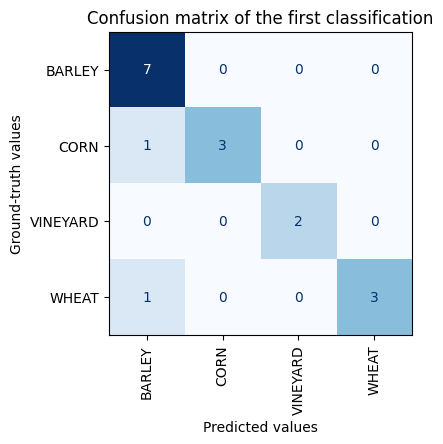

In [36]:
# Define figure size
cm = 1/2.54  # Conversion factor from cm to inches
fig, ax = plt.subplots(figsize=(10*cm, 10*cm))
#  Prepare the confusion matrix display
disp = ConfusionMatrixDisplay( confusion_matrix=CM, display_labels=representative_crops )
# Plot the confusion matrix 
disp.plot( colorbar=False, cmap='Blues',  xticks_rotation=90, ax=ax )
# Customize labels and title
ax.set_ylabel('Ground-truth values')   # True crop classes
ax.set_xlabel('Predicted values')  # Predicted crop classes
ax.set_title('Confusion matrix of the first classification')   # Title of the plot

### Visualize Parcels with True vs Predicted Classes on a Map

In [37]:
# --- Step 1: Create DataFrames for train and test with true/predicted values ---
dfgraf_train = pd.DataFrame({'y_train': y_train, 'prediction_train': prediction_train}, index=y_train.index)
dfgraf_test = pd.DataFrame({'y_test': y_test, 'prediction_test': prediction_test}, index=y_test.index)

# Join parcelID and geometry information from the main dataframe
dfgraf_train = gdfclas_nonans[['parcelID', 'geometry']].join(dfgraf_train, how='inner')
dfgraf_test = gdfclas_nonans[['parcelID', 'geometry']].join(dfgraf_test, how='inner')

# Convert to GeoDataFrames with proper CRS
gdfgraf_train = gpd.GeoDataFrame(dfgraf_train, geometry='geometry', crs='EPSG:25830')
gdfgraf_test = gpd.GeoDataFrame(dfgraf_test, geometry='geometry', crs='EPSG:25830')

#Display the new created geodataframe
gdfgraf_train.head(2)

,parcelID,geometry,y_train,prediction_train
0,163-3-473-1,"POLYGON ((606768.439 4687919.167, 606776.881 4...",1,1
1,163-3-490-2,"POLYGON ((606688.524 4687663.031, 606697.957 4...",4,4


In [38]:
# --- Step 2: Define a color dictionary for each crop class ---
color_dict = {
    1:'#1f77b4', 2:'#ff7f0e', 3:'#2ca02c', 4:'#d62728',
}

In [39]:
# --- Step 3: Explode MultiPolygons to separate rows for plotting ---
dfgraf_train_plot = gdfgraf_train.explode(index_parts=False).reset_index(drop=True)
dfgraf_test_plot = gdfgraf_test.explode(index_parts=False).reset_index(drop=True)

In [40]:
# --- Step 4: Define a helper function to add GeoDataFrames as layers ---
def add_gdf_layer(m, gdf, color_col, layer_name, tooltip_cols=None, color_map=None):
    """
    Add a GeoDataFrame as a Folium layer.
    Parameters:
        m: folium.Map
        gdf: GeoDataFrame (in EPSG:4326)
        color_col: column with the class to determine color
        layer_name: name of the layer
        tooltip_cols: columns to show in the tooltip
        color_map: dictionary mapping class numbers to colors
    """
    layer = folium.FeatureGroup(name=layer_name)
    for _, row in gdf.iterrows():
        # Determine the fill color for this parcel
        color = color_map[row[color_col]] if color_map else 'blue'
        # Create tooltip text from selected columns
        tooltip_text = "<br>".join([f"{col}: {row[col]}" for col in tooltip_cols]) if tooltip_cols else None
        # Map class numbers to crop names for tooltip
        if tooltip_text:
            tooltip_text = tooltip_text.replace('prediction_','Prediction (').replace('y_', 'Ground-truth (')
            tooltip_text = tooltip_text.replace('train','Train)').replace('test','Test)')
            crop_num = int(tooltip_text.split(':')[-1])
            crop_name = number_to_crop[crop_num]
            tooltip_text = ' '.join(tooltip_text.split(' ')[:-1] + [crop_name])
        # Add the parcel polygon to the layer
        folium.GeoJson(
            mapping(row['geometry']),
            style_function=lambda x, color=color: {
                'fillColor': color,
                'color': 'black',
                'weight': 0.1,
                'fillOpacity': 1
            },
            tooltip=tooltip_text
        ).add_to(layer)
    layer.add_to(m)


In [41]:
# --- Step 5: Prepare the map centered on test dataset ---
dfgraf_test_wgs84 = dfgraf_test_plot.to_crs(epsg=4326)
minx, miny, maxx, maxy = dfgraf_test_wgs84.total_bounds
center = [(miny + maxy)/2, (minx + maxx)/2]

m = folium.Map(location=center, zoom_start=13, tiles=None)

# --- Step 7: Add base maps ---
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google', name='Google Satellite'
).add_to(m)
folium.TileLayer("OpenStreetMap", name="OSM").add_to(m)
folium.TileLayer("CartoDB positron", name="CartoDB Positron").add_to(m)

# --- Step 8: Add layers for train and test datasets using helper function ---
dfgraf_train_wgs84 = dfgraf_train_plot.to_crs(epsg=4326)
add_gdf_layer(m, dfgraf_train_wgs84, 'y_train', 'Ground-truth (train)',
              tooltip_cols=['parcelID', 'y_train'], color_map=color_dict)
add_gdf_layer(m, dfgraf_train_wgs84, 'prediction_train', 'Predictions (train)',
              tooltip_cols=['parcelID', 'prediction_train'], color_map=color_dict)
add_gdf_layer(m, dfgraf_test_wgs84, 'y_test', 'Ground-truth (test)',
              tooltip_cols=['parcelID', 'y_test'], color_map=color_dict)
add_gdf_layer(m, dfgraf_test_wgs84, 'prediction_test', 'Predictions (test)',
              tooltip_cols=['parcelID', 'prediction_test'], color_map=color_dict)

# --- Step 9: Add layer control to toggle layers ---
folium.LayerControl().add_to(m)

# --- Step 10: Create a legend for crop classes ---
legend_html = """
<div style="
    position: fixed; 
    bottom: 5px; left: 5px; width: 500px; 
    background-color: rgba(255, 255, 255, 0.9);
    border: 1px solid grey;
    z-index:9999; font-size:9px;
    padding: 10px; border-radius: 10px;
">
<div style="display: grid; grid-template-columns: repeat(6, 1fr); grid-gap: 4px; margin-top: 6px;">
"""
for c in sorted(color_dict.keys()):
    class_name = number_to_crop[c]
    legend_html += f"""
    <div style="display: flex; align-items: center;">
        <div style='background:{color_dict[c]}; width:12px;height:12px; margin-right:5px; border:1px solid #555;'></div>
        {class_name}
    </div>
    """
legend_html += "</div></div>"

# Add legend to map
m.get_root().html.add_child(folium.Element(legend_html))

# --- Step 11: Display map ---
m